<a href="https://colab.research.google.com/github/THEJoshinator20/ST554-HW/blob/main/554_HW5_McClure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Homework 5

##Part 1 - Concepts

1. We discussed the “Five V’s of Big Data”. Give an example of a place where you’ve encountered big
data or a topic you are interested in where big data would arise. Specifically address the five V’s for
the example and whether/how they apply to your example. (5 pts)

The Five V's of Big Data are Volume, Variety, Velocity, Veracity, and Value.

In the past I worked on some financial data I got through Kaggle and it had volume and variety coming in at roughly 150,000 observations or so with some of these observations having completely unique observations. But more importantly the data had to be cleaned to get what was needed for the project which brough up some points of trying to ensure the data we were left with was needed and was as clean as possible.

2. Read about the database we’ll use below (part IV). Give an example for each letter in the CRUD acronym
in the context of this database. (3 pts)

Steps of an SQL:

C - Create in order to add in a new players stats

R - Read in order to retrieve a players batting average

U - Update in order to modify a salery or score

D - Delete in order to remove an error that has been made inputting the data

3. What is the purpose of the HAVING clause when writing SQL code? (Recall the sqlitetutorial.net tutorial
on the SELECT statement.) (3 pts)


It acts as a subfunction of a SQL allowing it to perform its function or augment its normal function to suit the purposes that the programmer requires.

#Part II - Simulation of a Sampling Distribution

4. We looked at using simulation to investigate the sampling distribution of pˆ in the notes. We’ll now
look at the sampling distribution of the sample slope from an SLR model using simulation.

• Recall we assume the following model for SLR:
$$Yi = β0 + β1xi + Ei$$
where the Ei are assumed to be indendent and identically distributed from a Normal distribution
with mean 0 and variance σ
2 . Let’s assume σ
2 = 1 for simplicity.

• We can generate data from this model by assuming values for β0, β1, and n, along with a sequence
of x values via the following code:

• Now we can use sklearn to obtain the estimate for the slope (and save that value) as we did
earlier in the course.

• Repeat the above process 5000 times. To be specific: (11 pts)
    
  * Generate the y values using the code with rng.standard_normal()

  * Find the ‘best’ slope via sklearn
  
  * Save that slope in some object

• We can use the many values of the sample slope as an approximation to the sampling distribution
of the sample slope! Create a histogram of the sample slope values you found. (3 pts)

• Use your sampling distribution to approximate the probability of observing a sample slope larger
than 1.65. This can be done by looking at the proportion of simulated values larger than 1.65. (3
pts)

• Give an interpretation of this value and why it might be important for us in relation to a hypothesis
test. (3 pts)

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

The probability of observing a sample slope larger than 1.65 is 1.0
Since the probability of the observing the sample slope being greater than 1.65 is 1
that the value that we chose as our testing number is too small and without difficulty
we accept the null hypothesis.


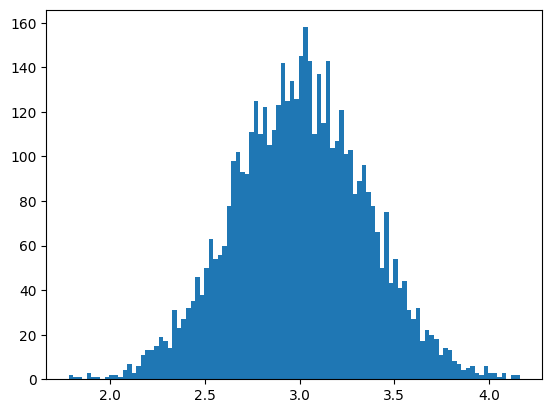

In [102]:
# Slope and Intercept library
slope = []
intercept = []

# Select random numbers for variables
n = 100
b0 = 12
b1 = 3

# Select sigma
sigma = 1

# Set seed for the for loop
rng = np.random.default_rng(22)

# For loop to get 5000 elements
for i in range(5000):

  # Calculate x
  x = rng.random(n)

  # Calculate error though by defult the sigma and mean should be 0 and 1
  e = sigma * rng.standard_normal(size=n)

  # Construct the model
  y = b0 + b1 * x + e

  # Sklearn producing linear regression model
  model = LinearRegression()
  model.fit(x.reshape(-1, 1), y)

  # Adding Model slope and intercept to libraries
  slope.append(model.coef_[0])
  intercept.append(model.intercept_)

# ------------------------------------------------------------------------- #

hist = plt.hist(slope, bins=100)

# ------------------------------------------------------------------------- #

prob = np.mean(np.array(slope) > 1.65)
print(f"The probability of observing a sample slope larger than 1.65 is {prob}")

# ------------------------------------------------------------------------- #

# Changed the string to a raw string (r"...") to ignore invalid escape sequence warning
print(r"Since the probability of the observing the sample slope being greater than 1.65 is 1")
print(r"that the value that we chose as our testing number is too small and without difficulty")
print(r"we accept the null hypothesis.")

#Part III - Big Data Examples & Rare Events

5. Consider this article about bias in machine learning models

• Pick an example in the article and briefly outline the issue around the data used to fit the model.
(3 pts)

• Describe how we might augment the data or otherwise account for the bias in that situation. (3
pts)


Example: In the article there is a section that talks about the review of weaponry that can be used in war. They have the power after meeting to 'ban' the weapon from further use making it so if that weapon was used again outside intervention would occur. The bias that could affect this is human in nature coming from political or emotional opinions/feelings. Even if models and procedures account for this bias it can't remove the bias. This is because environment and situations can affect decisions so it ceases to be a general bias and becomes a more unique bias.




Solution: The solution to this bias would be to limit the circumstances. A ruling must be made either blinded by the circumstances that is used in, without knowing who it is used on, or without knowing how the description of the damage of the weapon. As well as just making the decision a simple yes and no instead of a discussion.


---



6. Consider this article about big data usage in the Earth Sciences

• Choose one of the three major areas the paper discusses. Summarize the use of big data there.
Are there any biases or other missing data that might affect results? (I know this is likely difficult
as most of us aren’t experts in Earth science - just do your best - my goal is to try to get us to
always ask questions about the data collected and used for a study!) (5 pts)





So in surface water models the big data is used to help model the amount of water present as well as the amount of water being replenished. How the water is being stored in the ground or on the surface accounting for the material used and the material the water needs to pass through. There are environmental and human biases from both machines that take the data making incorrect readings or might diactivate/malfunction. There are the human error in the transfering of that essental information or the wrongful takes on outliers while processing the data. As well as assumptions of data that should occur clouding the observation of data that is presented.


---



7. Read through this short article: Article

• Mostly I just want you to read this article to understand some ways in which rare events, and
statisticians, play a role in different places. To have something to put here, can you think of
another variable or scenario where understanding rare events is important? (3 pts)

In clinical studies seeing drug interactions and adverse effects are for the most part a rare event. It is taken at a higher prority since the severity of the adverse event can effect whether or not the drug interaction can be considered like headaches vs temporary blindness.


---



#Part IV - Querying a database

There is a database file on the assignment link called Lahman.db that is an sqlite database downloaded from
here. This database has information on Major League Baseball.



8. Connect to the database (probably by uploading to Colab) and then look at all of the tables in the
database (use read_sql() from pandas to have this returned as a data frame).

In [31]:
# Read in Lahman Dataset
data = pd.read_sql("SELECT * FROM sqlite_master WHERE type='table'", "sqlite:////content/lahman_1871-2022.sqlite")
data


,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


9. Write an SQL query using pd.read_sql() that returns all the teams that played in the year 2015 with
all of the corresponding columns from the Teams table.

In [40]:
teams2015 = run_sql_query("SELECT * FROM Teams WHERE yearid == 2015")
teams2015

,yearID,lgID,teamID,franchID,divID,Rank,G,Ghome,W,L,...,DP,FP,name,park,attendance,BPF,PPF,teamIDBR,teamIDlahman45,teamIDretro
0,2015,AL,BAL,BAL,E,3,162,78,81,81,...,134,0.987,Baltimore Orioles,Oriole Park at Camden Yards,2281202,103,104,BAL,BAL,BAL
1,2015,AL,BOS,BOS,E,5,162,81,78,84,...,148,0.984,Boston Red Sox,Fenway Park II,2880694,104,107,BOS,BOS,BOS
2,2015,AL,CHA,CHW,C,4,162,81,76,86,...,159,0.983,Chicago White Sox,U.S. Cellular Field,1755810,92,93,CHW,CHA,CHA
3,2015,AL,CLE,CLE,C,3,161,80,81,80,...,136,0.987,Cleveland Indians,Progressive Field,1388905,106,106,CLE,CLE,CLE
4,2015,AL,DET,DET,C,5,161,81,74,87,...,165,0.986,Detroit Tigers,Comerica Park,2726048,97,98,DET,DET,DET
5,2015,AL,HOU,HOU,W,2,162,81,86,76,...,131,0.986,Houston Astros,Minute Maid Park,2153585,97,99,HOU,HOU,HOU
6,2015,AL,KCA,KCR,C,1,162,81,95,67,...,138,0.985,Kansas City Royals,Kauffman Stadium,2708549,104,103,KCR,KCA,KCA
7,2015,AL,LAA,ANA,W,3,162,81,85,77,...,108,0.984,Los Angeles Angels of Anaheim,Angel Stadium of Anaheim,3012765,94,95,LAA,ANA,ANA
8,2015,AL,MIN,MIN,C,2,162,81,83,79,...,150,0.986,Minnesota Twins,Target Field,2220054,103,104,MIN,MIN,MIN
9,2015,AL,NYA,NYY,E,2,162,81,87,75,...,135,0.985,New York Yankees,Yankee Stadium III,3193795,99,101,NYY,NYA,NYA


10. Write an SQL query using pd.read_sql() that returns all of the players in the hall of fame, the year
they were voted into the hall of fame, and their category - see the HallOfFame table, the inducted
variable is important here.

In [39]:
hall_of_fame_data = run_sql_query("SELECT * FROM HallOfFame")
hall_of_fame_data

,playerID,yearid,votedBy,ballots,needed,votes,inducted,category,needed_note
0,aaronha01,1982,BBWAA,415.0,312.0,406.0,Y,Player,None
1,abbotji01,2005,BBWAA,516.0,387.0,13.0,N,Player,None
2,abreubo01,2020,BBWAA,397.0,298.0,22.0,N,Player,None
3,abreubo01,2021,BBWAA,401.0,301.0,35.0,N,Player,None
4,abreubo01,2022,BBWAA,394.0,296.0,34.0,N,Player,None
...,...,...,...,...,...,...,...,...,...
4318,zambrca01,2018,BBWAA,422.0,317.0,0.0,N,Player,None
4319,zeileto01,2010,BBWAA,539.0,405.0,0.0,N,Player,None
4320,zimmech01,1938,BBWAA,262.0,197.0,1.0,N,Player,None
4321,ziskri01,1989,BBWAA,447.0,336.0,0.0,N,Player,None


11. Write an SQL query using pd.read_sql() that return all unique managers of the Pittsburgh Pirates (teamID of PIT) and only that information from the Managers table. Hint: Check out SELECT
DISTINCT

In [59]:
uniqmanagers = run_sql_query("SELECT DISTINCT playerID FROM Managers WHERE teamid = 'PIT'")
uniqmanagers

,playerID
0,bezdehu99
1,bragabo01
2,buckeal99
3,burnsto01
4,burwebi01
5,bushdo01
6,callani01
7,clarkfr01
8,davissp01
9,donovpa01


12. Use SQL code and the HallOfFame and Managers tables to return all of the playerIDs for the people
that managed for a team that were inducted into the hall of fame. Also, programmatically report
the number of such people - this can be done in pandas after returning the data from the call to
pd.read_sql().

In [68]:
hall_of_fame_data = run_sql_query("SELECT * FROM HallOfFame")
uniqmanagers = run_sql_query("SELECT * FROM Managers")


hallmanagers = run_sql_query("SELECT DISTINCT Managers.playerID FROM Managers INNER JOIN HallOfFame ON Managers.playerID = HallOfFame.playerID")
hallmanagers

,playerID
0,allisdo01
1,alomasa02
2,aloufe01
3,alstowa01
4,andersp01
...,...
245,wrighge01
246,wrighha01
247,yorkru01
248,youngcy01


13. Now use the same two tables (HallOfFame and Managers) and an SQL query to return every season
managed by each manager that made it to the hall of fame (so do this with an SQL join, not via
pd.merge()). You should return the playerID (manager ID), G, W, and L columns from the Managers
table.
Second, determine the overall win/loss records (sum of wins and sum of losses) for each of these hall
of fame managers. Third, create a new variable that is the win/loss percentage (W/(W+L)). Lastly, sort
the resulting data by the win/loss percentage variable (from largest to smallest). The last three parts
can be done in pandas with the returned data or you can do it via SQL in your call to pd.read_sql().


In [97]:
hall_of_fame_data = run_sql_query("SELECT * FROM HallOfFame")
uniqmanagers = run_sql_query("SELECT * FROM Managers")
hallmanagers = run_sql_query("SELECT DISTINCT Managers.playerID, Managers.G, Managers.W, Managers.L FROM Managers INNER JOIN HallOfFame ON Managers.playerID = HallOfFame.playerID")
hallmanagers

data = pd.DataFrame(hallmanagers)
data['W/L'] = data['W'] / (data['W'] + data['L'])
data['W/L'] = data['W/L'].round(2)
data['W/L'] = pd.to_numeric(data['W/L'])
data = data.sort_values(by='W/L', ascending=False) # Assign the sorted DataFrame back to 'data' and sort from largest to smallest
print(data)

       playerID  G  W  L  W/L
640   hardeme01  2  2  0  1.0
639   hardeme01  1  1  0  1.0
746   hornsro01  4  4  0  1.0
701   hermabi01  2  2  0  1.0
1440  speiech01  1  1  0  1.0
...         ... .. .. ..  ...
942   lathaar01  3  0  3  0.0
1564  trammal01  1  0  1  0.0
539   garneph01  6  0  6  0.0
958   loberha01  2  0  2  0.0
1713   yorkru01  1  0  1  0.0

[1716 rows x 5 columns]
